# Synthetic GMLC - Regional Load

Visualization of the day-ahead regional load time series in
`data/GMLC_ts_data/DAY_AHEAD_regional_Load.csv` for the three RTS-GMLC regions.

Colors use the Okabe-Ito colorblind-safe palette; region -> color is fixed everywhere below.

In [44]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

REPO = Path.cwd()
while not (REPO / "data").is_dir() and REPO != REPO.parent:
    REPO = REPO.parent
CSV = REPO / "data" / "GMLC_ts_data" / "Load" / "DAY_AHEAD_regional_Load.csv"
print("CSV:", CSV, CSV.exists())

REGIONS = ["1", "2", "3"]
LABELS = {"1": "Region 1", "2": "Region 2", "3": "Region 3"}
COLORS = {"1": "#0072B2", "2": "#D55E00", "3": "#009E73"}

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#DDDDDD",
    "grid.linewidth": 0.6,
    "axes.edgecolor": "#888888",
    "font.size": 9,
})

CSV: c:\Users\JKLCh\Desktop\ND_PhD\Research\GNN_PCM\data\GMLC_ts_data\Load\DAY_AHEAD_regional_Load.csv True


In [22]:
df = pd.read_csv(CSV)
# Period is the hour-of-day index 1..24
df["timestamp"] = (
    pd.to_datetime(dict(year=df.Year, month=df.Month, day=df.Day))
    + pd.to_timedelta(df.Period - 1, unit="h")
)
df = df.set_index("timestamp").sort_index()
load = df[REGIONS].astype(float)
load["Total"] = load.sum(axis=1)

print(load.index.min(), "->", load.index.max(), f"({len(load)} hourly points)")
load[REGIONS].describe().round(1)

2020-01-01 00:00:00 -> 2020-12-31 23:00:00 (8784 hourly points)


,1,2,3
count,8784.0,8784.0,8784.0
mean,1385.4,1387.6,1513.9
std,409.5,408.6,308.7
min,858.8,807.9,925.5
25%,1095.7,1105.8,1244.7
50%,1237.8,1237.7,1498.5
75%,1575.4,1536.9,1716.7
max,2850.0,2850.0,2850.0


## Full-year hourly load

One panel per region (small multiples); a shared y-axis keeps magnitudes comparable.

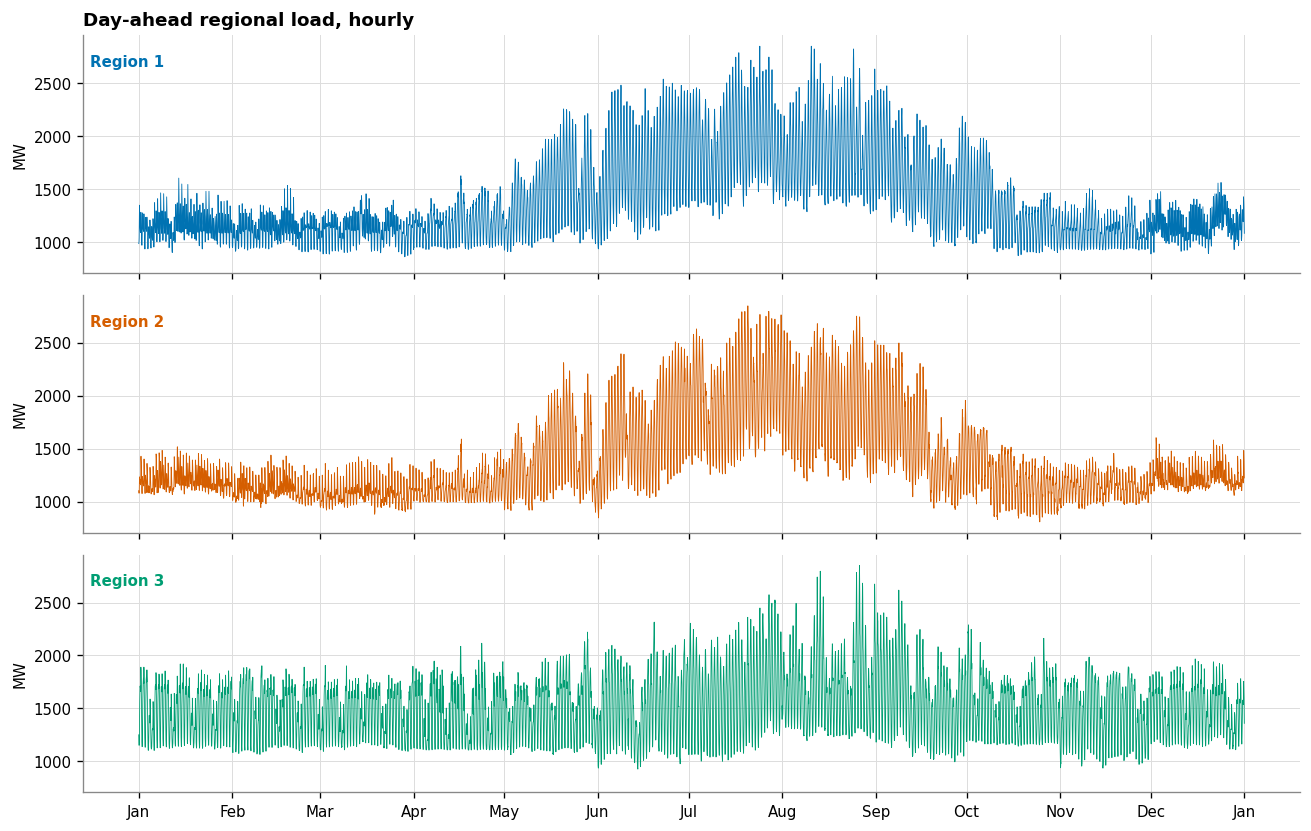

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True, sharey=True)
for ax, r in zip(axes, REGIONS):
    ax.plot(load.index, load[r], color=COLORS[r], lw=0.5)
    ax.set_ylabel("MW")
    ax.text(0.005, 0.92, LABELS[r], transform=ax.transAxes,
            color=COLORS[r], fontweight="bold", va="top")
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
axes[0].set_title("Day-ahead regional load, hourly", loc="left", fontsize=11, fontweight="bold")
fig.tight_layout()
plt.show()

## Overlaid comparison

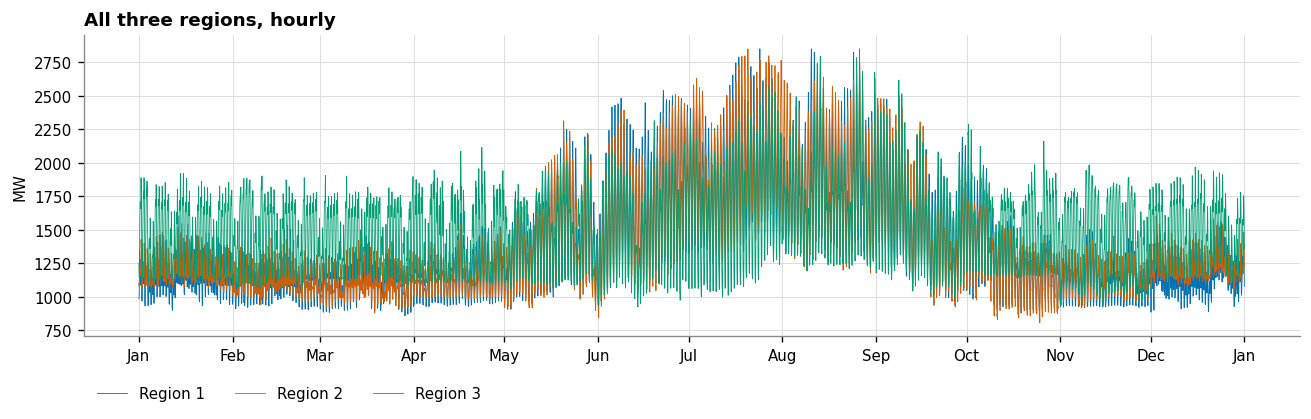

In [24]:
fig, ax = plt.subplots(figsize=(11, 3.6))
for r in REGIONS:
    ax.plot(load.index, load[r], color=COLORS[r], lw=0.5, label=LABELS[r])
ax.set_ylabel("MW")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.set_title("All three regions, hourly", loc="left", fontsize=11, fontweight="bold")
ax.legend(frameon=False, ncol=3, loc="upper left", bbox_to_anchor=(0, -0.12))
fig.tight_layout()
plt.show()

## Monthly average load

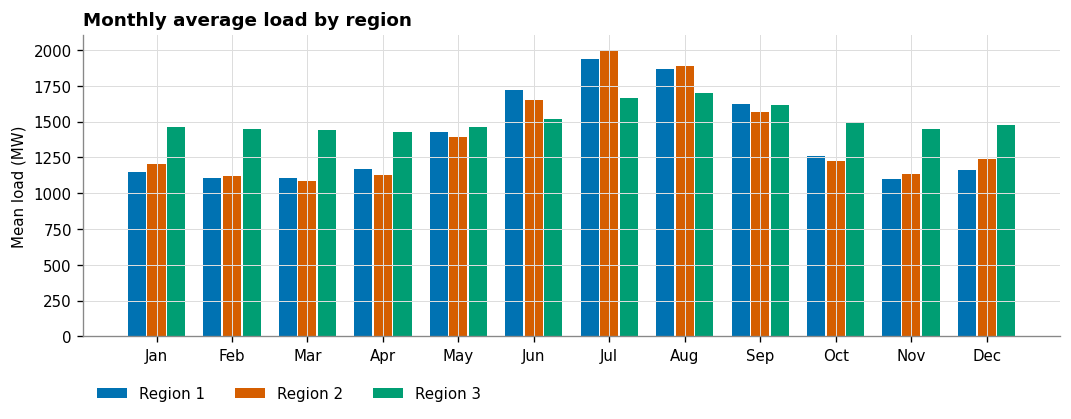

In [25]:
monthly = load[REGIONS].resample("MS").mean()

fig, ax = plt.subplots(figsize=(9, 3.6))
x = np.arange(len(monthly))
w = 0.26
for i, r in enumerate(REGIONS):
    ax.bar(x + (i - 1) * w, monthly[r], width=w - 0.02, color=COLORS[r], label=LABELS[r])
ax.set_xticks(x)
ax.set_xticklabels([d.strftime("%b") for d in monthly.index])
ax.set_ylabel("Mean load (MW)")
ax.set_title("Monthly average load by region", loc="left", fontsize=11, fontweight="bold")
ax.legend(frameon=False, ncol=3, loc="upper left", bbox_to_anchor=(0, -0.12))
fig.tight_layout()
plt.show()

## Average daily shape, by season

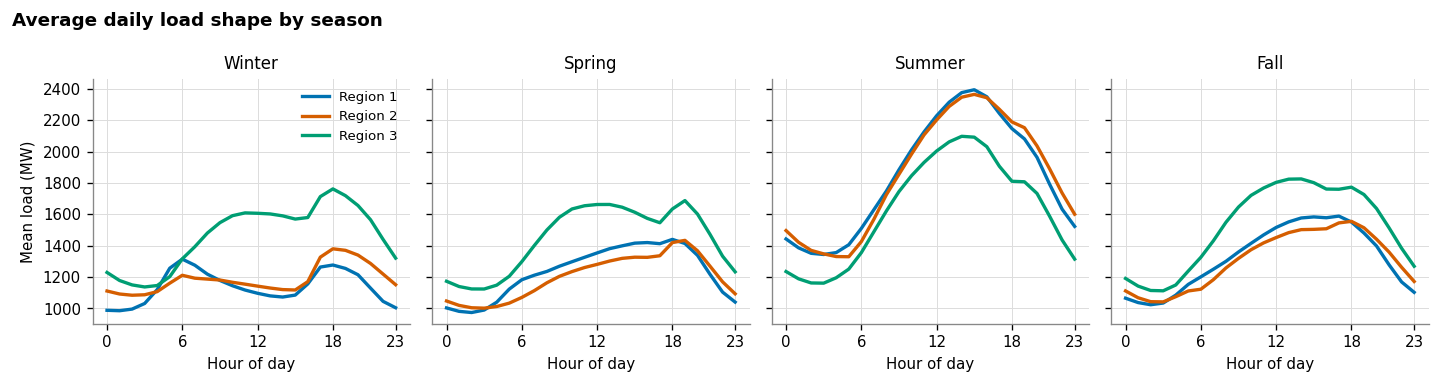

In [26]:
prof = load[REGIONS].copy()
prof["hour"] = prof.index.hour
prof["season"] = prof.index.month.map(
    {12: "Winter", 1: "Winter", 2: "Winter", 3: "Spring", 4: "Spring", 5: "Spring",
     6: "Summer", 7: "Summer", 8: "Summer", 9: "Fall", 10: "Fall", 11: "Fall"})

seasons = ["Winter", "Spring", "Summer", "Fall"]
fig, axes = plt.subplots(1, 4, figsize=(12, 3.2), sharey=True)
for ax, s in zip(axes, seasons):
    sub = prof[prof.season == s].groupby("hour")[REGIONS].mean()
    for r in REGIONS:
        ax.plot(sub.index, sub[r], color=COLORS[r], lw=2, label=LABELS[r])
    ax.set_title(s, fontsize=10)
    ax.set_xlabel("Hour of day")
    ax.set_xticks([0, 6, 12, 18, 23])
axes[0].set_ylabel("Mean load (MW)")
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle("Average daily load shape by season", x=0.005, ha="left",
             fontsize=11, fontweight="bold")
fig.tight_layout()
plt.show()

## Load duration curves

Hourly load sorted high to low, plus per-region summary statistics.

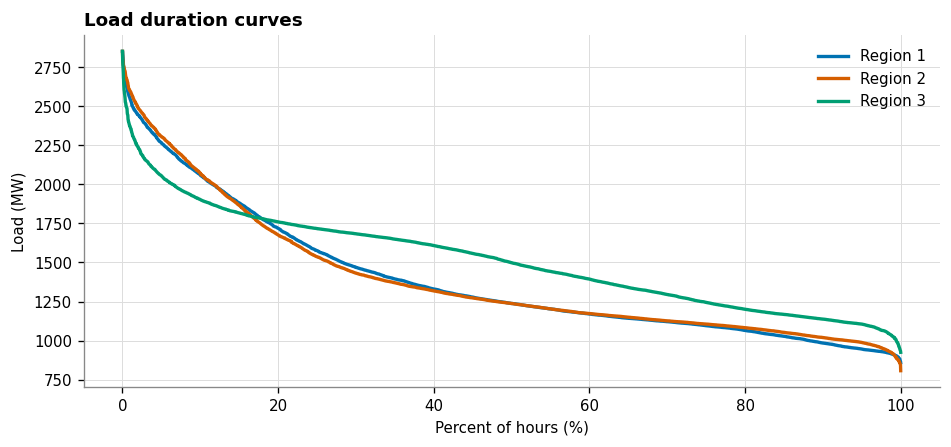

,Peak (MW),Mean (MW),Min (MW),Load factor,Energy (GWh)
Region 1,2850.0,1385.391,858.808,0.486,12169.270
Region 2,2850.0,1387.595,807.941,0.487,12188.636
Region 3,2850.0,1513.877,925.506,0.531,13297.893


In [27]:
fig, ax = plt.subplots(figsize=(8, 3.8))
pct = np.linspace(0, 100, len(load))
for r in REGIONS:
    ax.plot(pct, np.sort(load[r].values)[::-1], color=COLORS[r], lw=2, label=LABELS[r])
ax.set_xlabel("Percent of hours (%)")
ax.set_ylabel("Load (MW)")
ax.set_title("Load duration curves", loc="left", fontsize=11, fontweight="bold")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

summary = pd.DataFrame({
    "Peak (MW)": load[REGIONS].max(),
    "Mean (MW)": load[REGIONS].mean(),
    "Min (MW)": load[REGIONS].min(),
    "Load factor": load[REGIONS].mean() / load[REGIONS].max(),
    "Energy (GWh)": load[REGIONS].sum() / 1e3,
}).round(3)
summary.index = [LABELS[r] for r in REGIONS]
summary

## Peak week

The week around the system-wide peak hour.

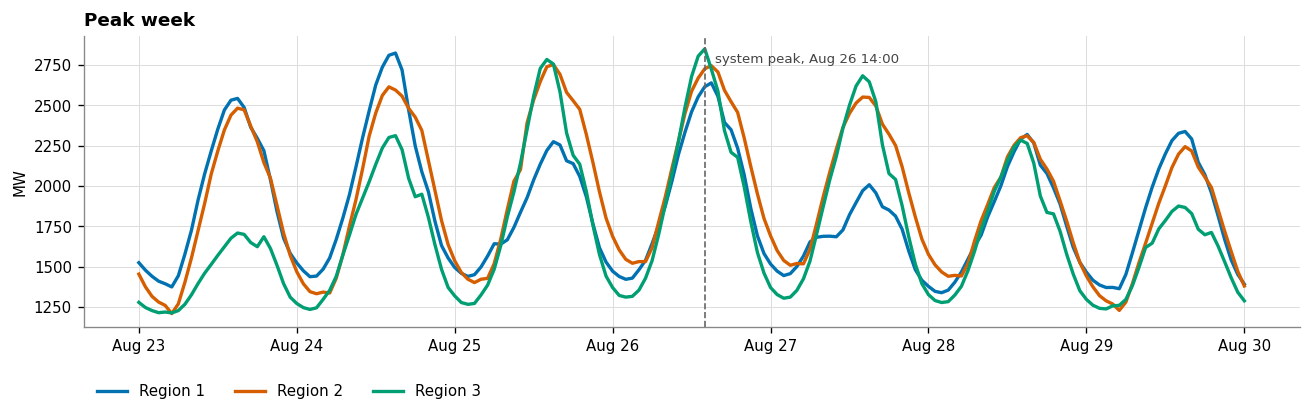

In [28]:
peak_ts = load["Total"].idxmax()
start = (peak_ts - pd.Timedelta(days=3)).normalize()
win = load.loc[start:start + pd.Timedelta(days=7)]

fig, ax = plt.subplots(figsize=(11, 3.6))
for r in REGIONS:
    ax.plot(win.index, win[r], color=COLORS[r], lw=2, label=LABELS[r])
ax.axvline(peak_ts, color="#666666", lw=1, ls="--")
ax.annotate(f"system peak, {peak_ts:%b %d %H:%M}", xy=(peak_ts, ax.get_ylim()[1]),
            xytext=(6, -10), textcoords="offset points", fontsize=8,
            color="#444444", va="top")
ax.set_ylabel("MW")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.set_title("Peak week", loc="left", fontsize=11, fontweight="bold")
ax.legend(frameon=False, ncol=3, loc="upper left", bbox_to_anchor=(0, -0.15))
fig.tight_layout()
plt.show()

---

# Synthetic load profiles

For each region $i$ and hour $t$, the synthetic load is the original profile plus a
multiplicative perturbation of itself:

$$l^i_t = \hat{l}^i_t + f^i_t \cdot \hat{l}^i_t = (1 + f^i_t)\,\hat{l}^i_t$$

where $\hat{l}^i_t$ is the original (observed) load and $f^i_t$ is an AR(1) coefficient
process

$$f^i_t = (1-\alpha) f^i_{t-1} + \alpha \varepsilon^i_t, \qquad f^i_0 = 0, \qquad
\varepsilon^i_t \sim \mathcal{N}(0, 0.1)$$

with $\alpha = 0.05$. Each region gets its own independent noise draw. Because
$|f^i_t| \ll 1$, the synthetic load stays strictly positive wherever the original is.

In [39]:
ALPHA = 0.05
EPS_STD = 0.1
SEED = 0

def simulate_f(n, alpha=ALPHA, eps_std=EPS_STD, rng=None, prev=0.0):
    """f_t = alpha * f_{t-1} + alpha * eps_t,  f_0 = 0,  eps_t ~ N(0, eps_std)."""
    rng = np.random.default_rng() if rng is None else rng
    eps = rng.normal(0.0, eps_std, size=n)
    f = np.empty(n)
    for t in range(n):
        prev = (1-alpha) * prev + alpha * eps[t]
        f[t] = prev
    return f

rng = np.random.default_rng(SEED)
n = len(load)

f_df = pd.DataFrame({r: simulate_f(n, rng=rng) for r in REGIONS}, index=load.index)

orig = load[REGIONS]
synth = orig + f_df * orig          # l^i_t = lhat^i_t + f^i_t * lhat^i_t
resid = synth - orig               # the perturbation itself, in MW

assert (synth > 0).all().all(), "synthetic load must stay positive"

pd.DataFrame({
    "f std": f_df.std(),
    "f min": f_df.min(),
    "f max": f_df.max(),
    "original mean (MW)": orig.mean(),
    "synthetic mean (MW)": synth.mean(),
    "synthetic min (MW)": synth.min(),
    "synthetic peak (MW)": synth.max(),
    "perturbation std (MW)": resid.std(),
}).round(4)

,f std,f min,f max,original mean (MW),synthetic mean (MW),synthetic min (MW),synthetic peak (MW),perturbation std (MW)
1,0.0169,-0.0602,0.0607,1385.3905,1386.3364,850.8370,2857.6145,24.2972
2,0.0163,-0.0564,0.0499,1387.5951,1388.7305,820.1875,2850.7333,23.7734
3,0.0148,-0.0473,0.0510,1513.8767,1514.3009,912.6511,2853.5454,22.8051


> **Note on the parameters.** With $\alpha = 0.05$ scaling both the AR term and the
> innovation, $f$ is close to white noise with $\operatorname{std}(f) \approx \alpha \cdot 0.1
> = 0.005$ — the 5% carryover decays in a single step, so there is very little temporal
> correlation. The synthetic load is therefore the original profile jittered by roughly
> $\pm 0.5\%$ (a few MW per hour). Raise $\alpha$ toward 1 for a perturbation that
> persists across hours, or raise `EPS_STD` for larger swings.

## The coefficient process $f^i_t$

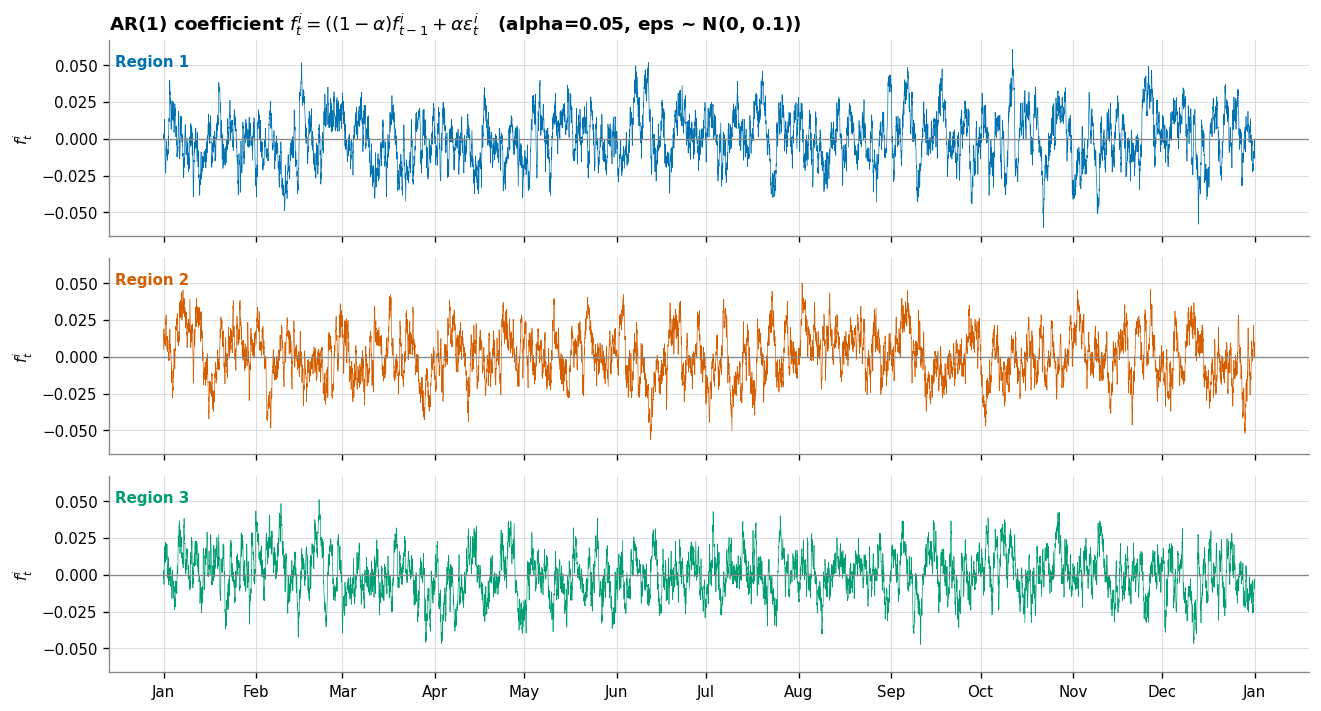

In [43]:
fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True, sharey=True)
for ax, r in zip(axes, REGIONS):
    ax.plot(f_df.index, f_df[r], color=COLORS[r], lw=0.4)
    ax.axhline(0, color="#888888", lw=0.8)
    ax.set_ylabel(r"$f^i_t$")
    ax.text(0.005, 0.93, LABELS[r], transform=ax.transAxes,
            color=COLORS[r], fontweight="bold", va="top")
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
axes[0].set_title(r"AR(1) coefficient $f^i_t = ((1-\alpha) f^i_{t-1} + \alpha \varepsilon^i_t$"
                  f"   (alpha={ALPHA}, eps ~ N(0, {EPS_STD}))",
                  loc="left", fontsize=11, fontweight="bold")
fig.tight_layout()
plt.show()

### First week of $f$, and its distribution

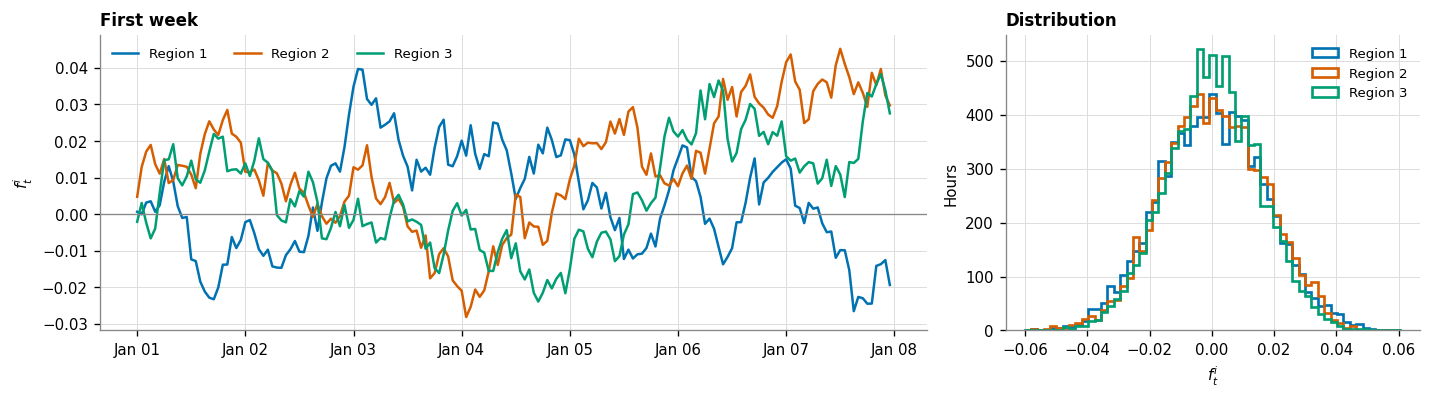

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4),
                         gridspec_kw={"width_ratios": [2, 1]})

wk = f_df.iloc[:24 * 7]
for r in REGIONS:
    axes[0].plot(wk.index, wk[r], color=COLORS[r], lw=1.5, label=LABELS[r])
axes[0].axhline(0, color="#888888", lw=0.8)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
axes[0].set_ylabel(r"$f^i_t$")
axes[0].set_title("First week", loc="left", fontsize=10, fontweight="bold")
axes[0].legend(frameon=False, ncol=3, fontsize=8)

bins = np.linspace(f_df.values.min(), f_df.values.max(), 60)
for r in REGIONS:
    axes[1].hist(f_df[r], bins=bins, histtype="step", lw=1.6,
                 color=COLORS[r], label=LABELS[r])
axes[1].set_xlabel(r"$f^i_t$")
axes[1].set_ylabel("Hours")
axes[1].set_title("Distribution", loc="left", fontsize=10, fontweight="bold")
axes[1].legend(frameon=False, fontsize=8)

fig.tight_layout()
plt.show()

## Synthetic load profiles $l^i_t = (1 + f^i_t)\,\hat{l}^i_t$

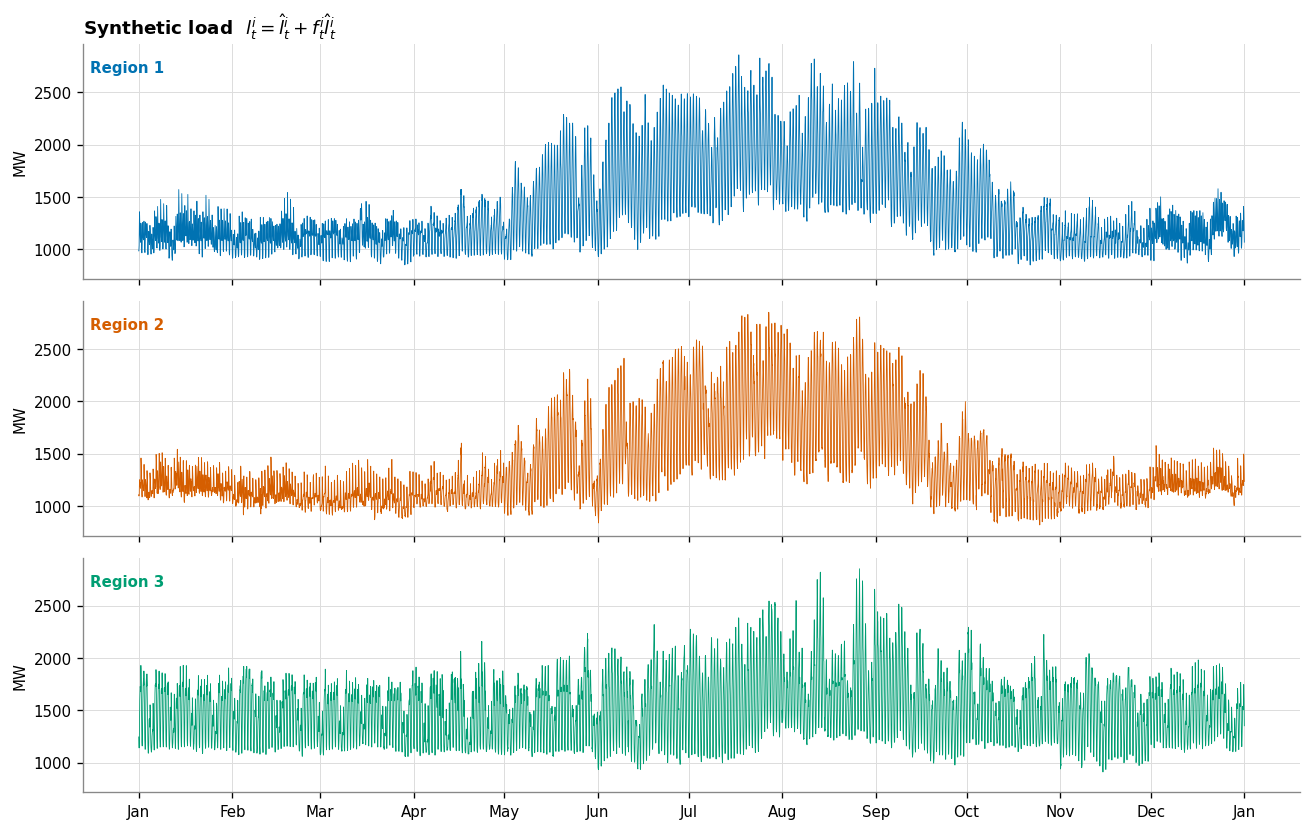

In [42]:
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True, sharey=True)
for ax, r in zip(axes, REGIONS):
    ax.plot(synth.index, synth[r], color=COLORS[r], lw=0.5)
    ax.set_ylabel("MW")
    ax.text(0.005, 0.93, LABELS[r], transform=ax.transAxes,
            color=COLORS[r], fontweight="bold", va="top")
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
axes[0].set_title(r"Synthetic load  $l^i_t = \hat{l}^i_t + f^i_t \hat{l}^i_t$",
                  loc="left", fontsize=11, fontweight="bold")
fig.tight_layout()
plt.show()

### Synthetic vs. original, first week

The original is drawn as a thick pale band, the synthetic series over it in the same hue.

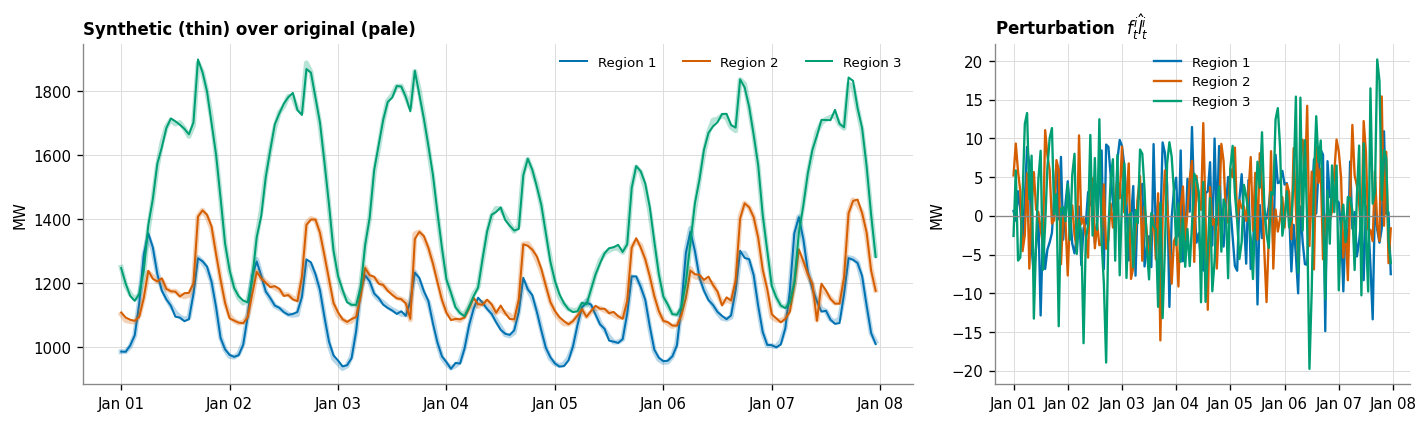

In [33]:
wk_idx = synth.index[:24 * 7]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6),
                         gridspec_kw={"width_ratios": [2, 1]})

for r in REGIONS:
    axes[0].plot(wk_idx, orig.loc[wk_idx, r], color=COLORS[r], lw=3.0, alpha=0.28)
    axes[0].plot(wk_idx, synth.loc[wk_idx, r], color=COLORS[r], lw=1.2, label=LABELS[r])
axes[0].set_ylabel("MW")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
axes[0].set_title("Synthetic (thin) over original (pale)", loc="left",
                  fontsize=10, fontweight="bold")
axes[0].legend(frameon=False, ncol=3, fontsize=8)

for r in REGIONS:
    axes[1].plot(wk_idx, resid.loc[wk_idx, r], color=COLORS[r], lw=1.4, label=LABELS[r])
axes[1].axhline(0, color="#888888", lw=0.8)
axes[1].set_ylabel("MW")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
axes[1].set_title(r"Perturbation  $f^i_t \hat{l}^i_t$", loc="left",
                  fontsize=10, fontweight="bold")
axes[1].legend(frameon=False, fontsize=8)

fig.tight_layout()
plt.show()

### Sanity check: the synthetic profile never goes negative

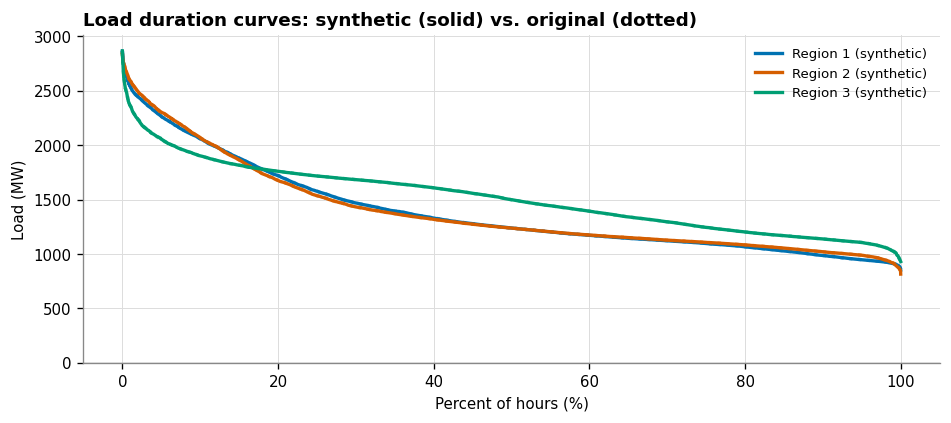

min synthetic load by region (MW):
1    852.702
2    814.493
3    929.480


In [34]:
fig, ax = plt.subplots(figsize=(8, 3.6))
pct = np.linspace(0, 100, len(synth))
for r in REGIONS:
    ax.plot(pct, np.sort(synth[r].values)[::-1], color=COLORS[r], lw=2,
            label=f"{LABELS[r]} (synthetic)")
    ax.plot(pct, np.sort(orig[r].values)[::-1], color=COLORS[r], lw=2,
            ls=":", alpha=0.6)
ax.axhline(0, color="#888888", lw=0.8)
ax.set_ylim(bottom=0)
ax.set_xlabel("Percent of hours (%)")
ax.set_ylabel("Load (MW)")
ax.set_title("Load duration curves: synthetic (solid) vs. original (dotted)",
             loc="left", fontsize=11, fontweight="bold")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

print("min synthetic load by region (MW):")
print(synth.min().round(3).to_string())